# Konfiguracja

In [39]:
import kagglehub
import pandas as pd
import os
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json

# Konfiguracja wizualna
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.width', 1000)
pd.set_option('display.float_format', '{:.2f}'.format)

import warnings
warnings.filterwarnings("ignore")

# Pobieranie danych

In [12]:
# Pobieramy zbiór danych "UK Used Car Dataset"
path = kagglehub.dataset_download("adityadesai13/used-car-dataset-ford-and-mercedes")

print("Ścieżka do folderu z danymi:", path)

# Sprawdźmy, jakie pliki tam są
files = [f for f in os.listdir(path) if f.endswith('.csv')]
print("\nZnalezione pliki CSV:")
print(files)

Ścieżka do folderu z danymi: C:\Users\konta\.cache\kagglehub\datasets\adityadesai13\used-car-dataset-ford-and-mercedes\versions\3

Znalezione pliki CSV:
['audi.csv', 'bmw.csv', 'cclass.csv', 'focus.csv', 'ford.csv', 'hyundi.csv', 'merc.csv', 'skoda.csv', 'toyota.csv', 'unclean cclass.csv', 'unclean focus.csv', 'vauxhall.csv', 'vw.csv']


In [15]:
# Lista na DataFrame'y z poszczególnych plików
all_data = []

# Słownik do naprawy nazw kolumn
column_mapping = {
    'tax(£)': 'tax',
    'fuel type': 'fuelType',
    'engine size': 'engineSize',
    'mileage': 'mileage' 
}

for file in files:
    # Pełna ścieżka do pliku
    file_path = os.path.join(path, file)
    
    # Wczytujemy plik
    temp_df = pd.read_csv(file_path)
    
    # Mapujemy kolumny
    temp_df = temp_df.rename(columns=column_mapping)

    # Wyciągamy nazwę marki z nazwy pliku (np. 'audi.csv' -> 'audi')
    make_name = file.replace('.csv', '').capitalize()
    
    # Dodajemy kolumnę 'Make', żeby wiedzieć, co to za marka
    temp_df['Make'] = make_name
    
    # Dodajemy do listy
    all_data.append(temp_df)
    print(f"Wczytano: {make_name} ({temp_df.shape[0]} wierszy)")

# Łączymy wszystko w jeden DataFrame
df = pd.concat(all_data, ignore_index=True)

cols_to_drop = [c for c in df.columns if '2' in c]

if cols_to_drop:
    df = df.drop(columns=cols_to_drop)
    print(f'Usunięto kolumny: {cols_to_drop}')

print("-" * 30)
print(f"SUKCES! Łączny rozmiar danych: {df.shape}")
print("-" * 30)

# Sprawdźmy próbkę
print(df.sample(5))

Wczytano: Audi (10668 wierszy)
Wczytano: Bmw (10781 wierszy)
Wczytano: Cclass (3899 wierszy)
Wczytano: Focus (5454 wierszy)
Wczytano: Ford (17965 wierszy)
Wczytano: Hyundi (4860 wierszy)
Wczytano: Merc (13119 wierszy)
Wczytano: Skoda (6267 wierszy)
Wczytano: Toyota (6738 wierszy)
Wczytano: Unclean cclass (4006 wierszy)
Wczytano: Unclean focus (5604 wierszy)
Wczytano: Vauxhall (13632 wierszy)
Wczytano: Vw (15157 wierszy)
Usunięto kolumny: ['mileage2', 'fuel type2', 'engine size2']
------------------------------
SUKCES! Łączny rozmiar danych: (118150, 11)
------------------------------
          model    year  price transmission mileage fuelType    tax   mpg engineSize      Make reference
2329         Q5 2016.00  29500    Semi-Auto   37500   Diesel 240.00 42.80       3.00      Audi       NaN
52443    Tucson 2017.00  13251       Manual   29968   Diesel  30.00 61.70       1.70    Hyundi       NaN
30990    Fiesta 2016.00   8498       Manual   21888   Petrol 125.00 54.30       1.20      Ford

In [20]:
print("\nLiczba braków (NaN) w kolumnach:")
print(df.isnull().sum())
print("-" * 30)
print(df.head())


Liczba braków (NaN) w kolumnach:
model              155
year               247
price              155
transmission       155
mileage           1073
fuelType          6093
tax              18963
mpg              18963
engineSize         265
Make                 0
reference       108695
dtype: int64
------------------------------
  model    year  price transmission mileage fuelType    tax   mpg engineSize  Make reference
0    A1 2017.00  12500       Manual   15735   Petrol 150.00 55.40       1.40  Audi       NaN
1    A6 2016.00  16500    Automatic   36203   Diesel  20.00 64.20       2.00  Audi       NaN
2    A1 2016.00  11000       Manual   29946   Petrol  30.00 55.40       1.40  Audi       NaN
3    A4 2017.00  16800    Automatic   25952   Diesel 145.00 67.30       2.00  Audi       NaN
4    A3 2019.00  17300       Manual    1998   Petrol 145.00 49.60       1.00  Audi       NaN


In [21]:
# Usuwanie kolumny 'reference'
if 'reference' in df.columns:
    df = df.drop(columns=['reference'])
    print('Usunięto kolumnę "reference"')

# Usuwanie wierszy z brakującymi danymi

df_clean = df.dropna()

print("-" * 30)
print(f"Rozmiar PRZED czyszczeniem: {df.shape}")
print(f"Rozmiar PO czyszczeniu:    {df_clean.shape}")
print("-" * 30)

# Sprawdzenie czy są braki danych
print("Czy są jeszcze jakieś braki?", df_clean.isnull().sum().sum())

print(df_clean.head())

Usunięto kolumnę "reference"
------------------------------
Rozmiar PRZED czyszczeniem: (118150, 10)
Rozmiar PO czyszczeniu:    (99187, 10)
------------------------------
Czy są jeszcze jakieś braki? 0
  model    year  price transmission mileage fuelType    tax   mpg engineSize  Make
0    A1 2017.00  12500       Manual   15735   Petrol 150.00 55.40       1.40  Audi
1    A6 2016.00  16500    Automatic   36203   Diesel  20.00 64.20       2.00  Audi
2    A1 2016.00  11000       Manual   29946   Petrol  30.00 55.40       1.40  Audi
3    A4 2017.00  16800    Automatic   25952   Diesel 145.00 67.30       2.00  Audi
4    A3 2019.00  17300       Manual    1998   Petrol 145.00 49.60       1.00  Audi


In [22]:
# Zapis czystego DataFrame do jednego pliku CSV
df_clean.to_csv("cars_clean.csv", index=False)

print("Sukces! Plik 'cars_clean.csv' został zapisany.")

Sukces! Plik 'cars_clean.csv' został zapisany.


In [24]:
df = pd.read_csv("cars_clean.csv")
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,Make
0,A1,2017.00,12500,Manual,15735,Petrol,150.00,55.40,1.40,Audi
1,A6,2016.00,16500,Automatic,36203,Diesel,20.00,64.20,2.00,Audi
2,A1,2016.00,11000,Manual,29946,Petrol,30.00,55.40,1.40,Audi
3,A4,2017.00,16800,Automatic,25952,Diesel,145.00,67.30,2.00,Audi
4,A3,2019.00,17300,Manual,1998,Petrol,145.00,49.60,1.00,Audi


In [28]:
cols_to_encoding = ['model', 'transmission','fuelType', 'Make']

df1 = pd.get_dummies(df,
                    columns=cols_to_encoding,
                    drop_first=True,
                    dtype=int)

df1.head()

,year,price,mileage,tax,mpg,engineSize,model_ 2 Series,model_ 3 Series,model_ 4 Series,model_ 5 Series,model_ 6 Series,model_ 7 Series,model_ 8 Series,model_ A Class,model_ A1,model_ A2,model_ A3,model_ A4,model_ A5,model_ A6,model_ A7,model_ A8,model_ Accent,model_ Adam,model_ Agila,model_ Amarok,model_ Amica,model_ Ampera,model_ Antara,model_ Arteon,model_ Astra,model_ Auris,model_ Avensis,model_ Aygo,model_ B Class,model_ B-MAX,model_ Beetle,model_ C Class,model_ C-HR,model_ C-MAX,model_ CC,model_ CL Class,model_ CLA Class,model_ CLC Class,model_ CLK,model_ CLS Class,model_ Caddy,model_ Caddy Life,model_ Caddy Maxi,model_ Caddy Maxi Life,model_ California,model_ Camry,model_ Caravelle,model_ Cascada,model_ Citigo,model_ Combo Life,model_ Corolla,model_ Corsa,model_ Crossland X,model_ E Class,model_ EcoSport,model_ Edge,model_ Eos,model_ Escort,model_ Fabia,model_ Fiesta,model_ Focus,model_ Fox,model_ Fusion,model_ G Class,model_ GL Class,model_ GLA Class,model_ GLB Class,model_ GLC Class,model_ GLE Class,model_ GLS Class,model_ GT86,model_ GTC,model_ Galaxy,model_ Getz,model_ Golf,model_ Golf SV,model_ Grand C-MAX,model_ Grand Tourneo Connect,model_ Grandland X,model_ Hilux,model_ I10,model_ I20,model_ I30,model_ I40,model_ I800,model_ IQ,model_ IX20,model_ IX35,model_ Insignia,model_ Ioniq,model_ Jetta,model_ KA,model_ Ka+,model_ Kadjar,model_ Kamiq,model_ Karoq,model_ Kodiaq,model_ Kona,model_ Kuga,model_ Land Cruiser,model_ M Class,model_ M2,model_ M3,model_ M4,model_ M5,model_ M6,model_ Meriva,model_ Mokka,model_ Mokka X,model_ Mondeo,model_ Mustang,model_ Octavia,model_ PROACE VERSO,model_ Passat,model_ Polo,model_ Prius,model_ Puma,model_ Q2,model_ Q3,model_ Q5,model_ Q7,model_ Q8,model_ R Class,model_ R8,model_ RAV4,model_ RS3,model_ RS4,model_ RS5,model_ RS6,model_ RS7,model_ Ranger,model_ Rapid,model_ Roomster,model_ S Class,model_ S-MAX,model_ S3,model_ S4,model_ S5,model_ S8,model_ SL CLASS,model_ SLK,model_ SQ5,model_ SQ7,model_ Santa Fe,model_ Scala,model_ Scirocco,model_ Sharan,model_ Shuttle,model_ Streetka,model_ Superb,model_ Supra,model_ T-Cross,model_ T-Roc,model_ TT,model_ Terracan,model_ Tigra,model_ Tiguan,model_ Tiguan Allspace,model_ Touareg,model_ Touran,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_ Tucson,model_ Up,model_ Urban Cruiser,model_ V Class,model_ Vectra,model_ Veloster,model_ Verso,model_ Verso-S,model_ Viva,model_ Vivaro,model_ X-CLASS,model_ X1,model_ X2,model_ X3,model_ X4,model_ X5,model_ X6,model_ X7,model_ Yaris,model_ Yeti,model_ Yeti Outdoor,model_ Z3,model_ Z4,model_ Zafira,model_ Zafira Tourer,model_ i3,model_ i8,model_180,model_200,model_220,model_230,model_Golf,transmission_Manual,transmission_Other,transmission_Semi-Auto,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,Make_Bmw,Make_Ford,Make_Hyundi,Make_Merc,Make_Skoda,Make_Toyota,Make_Vauxhall,Make_Vw
0,2017.00,12500,15735,150.00,55.40,1.40,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0
1,2016.00,16500,36203,20.00,64.20,2.00,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2016.00,11000,29946,30.00,55.40,1.40,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

# XGBoost

In [30]:
X = df1.drop('price', axis=1)
y = df1['price']

# Transofrmacja logarytmiczna targetu 
y_log = np.log1p(y)


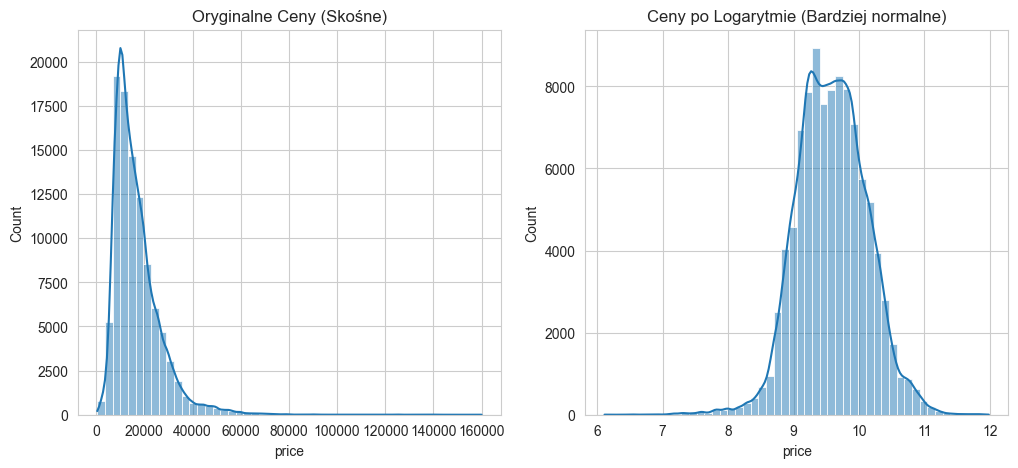

In [ ]:


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y, bins=50, kde=True)
plt.title("Oryginalne Ceny (Skośne)")

plt.subplot(1, 2, 2)
sns.histplot(y_log, bins=50, kde=True)
plt.title("Ceny po Logarytmie (Bardziej normalne)")
plt.show()

In [33]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X,
                                                            y_log,
                                                            test_size=0.2, 
                                                            random_state=42)
print(f'X_train shape: {X_train.shape}')
print(f'y_train_log shape: {y_train_log.shape}')

X_train shape: (79349, 215)
y_train_log shape: (79349,)


In [36]:
model_xgb = XGBRegressor(n_estimators=500,
                        learning_rate=0.05,
                        max_depth=7,
                        random_state=42,
                        n_jobs=1)

print('Rozpoczynam trening modelu...') 
model_xgb.fit(X_train, y_train_log)
print('Model wytrnowany') 


Rozpoczynam trening modelu...
Model wytrnowany


In [37]:
# 1. Predykcja (zwraca logarytm ceny!)
y_pred_log = model_xgb.predict(X_test)

# 2. ODWRÓCENIE LOGARYTMU (Wracamy do normalnych cen)
# expm1 to odwrotność log1p
y_pred = np.expm1(y_pred_log)
y_test_real = np.expm1(y_test_log)

# 3. Sprawdzenie błędów
mae = mean_absolute_error(y_test_real, y_pred)
r2 = r2_score(y_test_real, y_pred)

print("-" * 30)
print(f"Średni Błąd (MAE): {mae:.2f} GBP") 
print(f"Dopasowanie (R2):  {r2:.4f}") 
print("-" * 30)

------------------------------
Średni Błąd (MAE): 1302.78 GBP
Dopasowanie (R2):  0.9515
------------------------------


In [38]:
# Zapis modelu 
model_xgb.save_model('xgb_car_price_model.json')

print('Model został zapisany do pliku xgb_car_price_model.json')

Model został zapisany do pliku xgb_car_price_model.json


In [41]:
model_columns = list(X_train.columns)

with open('model_columns.json', 'w') as f:
    json.dump(model_columns, f)

print('Zapisano plik model_columns.json')

Zapisano plik model_columns.json
